# تثبيت المكتبات

In [ ]:
!pip install qiskit qiskit-aer tensorflow matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00


In [ ]:

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [ ]:
# إنشاء دائرة كمومية: 1 qubit و 1 classical bit
circuit = QuantumCircuit(1, 1)

# تطبيق بوابة Hadamard لجعل الكيوبت في حالة Superposition
circuit.h(0)

# قياس الكيوبت
circuit.measure(0, 0)

In [ ]:
# إنشاء المحاكي الكمومي
simulator = AerSimulator()

# تجهيز الدائرة للمحاكي
compiled_circuit = transpile(circuit, simulator)

In [ ]:

# تشغيل الدائرة 1000 مرة
job = simulator.run(compiled_circuit, shots=1000)

In [ ]:
# استخراج النتائج
result = job.result()
counts = result.get_counts()

print("Quantum Results:", counts)

Quantum Results: {'0': 478, '1': 522}


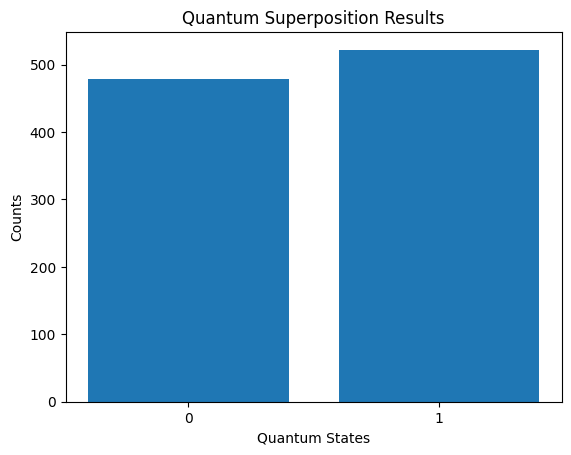

In [ ]:
# رسم النتائج
plt.bar(counts.keys(), counts.values())
plt.xlabel("Quantum States")
plt.ylabel("Counts")
plt.title("Quantum Superposition Results")
plt.show()


# Part 2: Neural Network using TensorFlow

In [ ]:

# إنشاء بيانات تدريب بسيطة
X_train = np.random.rand(100, 3)

In [ ]:

# إنشاء تصنيفات عشوائية: 0 أو 1
y_train = np.random.randint(2, size=(100, 1))


In [ ]:
# بناء شبكة عصبية بسيطة
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# تجهيز النموذج للتدريب
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:

# تدريب النموذج
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5200 - loss: 0.6934
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5200 - loss: 0.6927
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5200 - loss: 0.6922
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5200 - loss: 0.6916
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5200 - loss: 0.6912 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5200 - loss: 0.6907 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5300 - loss: 0.6904 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5400 - loss: 0.6899
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5600 - loss: 0.6896
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5700 - loss: 0.6895


In [ ]:
# تقييم النموذج
loss, accuracy = model.evaluate(X_train, y_train)

print("Neural Network Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 0.6891  
Neural Network Accuracy: 0.550000011920929


# Part 3: Simple Symbolic Rule
# NeuroSymbolic AI Idea

In [ ]:
# أخذ توقع من الشبكة العصبية
sample = np.array([[0.8, 0.6, 0.9]])
prediction = model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


In [ ]:
print("Neural Prediction:", prediction[0][0])

Neural Prediction: 0.49381468


In [ ]:
# قاعدة رمزية بسيطة
if prediction[0][0] >= 0.5:
    decision = "Class 1 - Accepted"
else:
    decision = "Class 0 - Rejected"

print("Symbolic Decision:", decision)

Symbolic Decision: Class 0 - Rejected
